<h1 align="center">Loan repayment prediction — EDA</h1>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Loading Data

In [2]:
train = pd.read_csv('../data/train.csv')

test = pd.read_csv('../data/test.csv')

# Shape & columns

In [3]:
summary = pd.DataFrame({
    'rows': [train.shape[0], test.shape[0]],
    'columns': [train.shape[1], test.shape[1]]
}, index=['train', 'test'])

summary

,rows,columns
train,593994,13
test,254569,12


In [4]:
missing_in_test = set(train.columns) - set(test.columns)
print(f"Columns in train but not test: {missing_in_test}")

Columns in train but not test: {'loan_paid_back'}


**Observations:**
- Train set has 593,994 rows and 13 columns (12 features + 1 target)
- Test set has 254,569 rows and 12 columns (no target column)
- `loan_paid_back` is only in train — confirmed as the target variable

## Data Inspection

In [5]:
train.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


**Observations:**
- Mix of numerical features: `annual_income`, `debt_to_income_ratio`, `credit_score`, `loan_amount`, `interest_rate`
- Mix of categorical features: `gender`, `marital_status`, `education_level`, `employment_status`, `loan_purpose`, `grade_subgrade`
- Target `loan_paid_back` is binary (0.0 or 1.0)
- `grade_subgrade` looks like a letter+number code (e.g. C3, D3, F1)

In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  str    
 7   marital_status        593994 non-null  str    
 8   education_level       593994 non-null  str    
 9   employment_status     593994 non-null  str    
 10  loan_purpose          593994 non-null  str    
 11  grade_subgrade        593994 non-null  str    
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), str(6)
memory usage: 58.9 MB


In [7]:
train['gender'].value_counts()

gender
Female    306175
Male      284091
Other       3728
Name: count, dtype: int64

3 different types, so it stays as str - not binary 

In [8]:
train['loan_paid_back'].unique()

array([1., 0.])

As expected only 2 values

In [9]:
train['education_level'].unique()

<StringArray>
['High School', 'Master's', 'Bachelor's', 'PhD', 'Other']
Length: 5, dtype: str

4 concrete types + 1 ambigious : `other`

**Observations:**
- No missing values — all 593,994 rows are complete across all 13 columns
- 5 float64 features, 2 int64 features, 6 categorical (string) features to be precise
- Dtype casting for some features is recommended:  loan_paid_back -> int (target variable), grade_subgrade -> ordinal, 
- `education_level` — has natural ordinal order (High School < Bachelor's < Master's < PhD) but `Other` is ambiguous so encoding strategy depends on final model choice
- str will need to be encoded
- ID  is a sequential row number with no predictive value, and it would confuse the model, so it needs to be dropped before training.

In [37]:
print(train.isnull().sum())

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64


Confirmed - no missing values

In [10]:
print(f"Duplicate rows: {train.duplicated().sum()}")
print(f"Duplicate IDs: {train['id'].duplicated().sum()}")

Duplicate rows: 0
Duplicate IDs: 0


**Observation:**
- No duplicate rows found — dataset is clean.

In [11]:
for col in train.select_dtypes(include='str').columns:
    print(f"\n{col}:\n{train[col].unique()}")


gender:
<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

marital_status:
<StringArray>
['Single', 'Married', 'Divorced', 'Widowed']
Length: 4, dtype: str

education_level:
<StringArray>
['High School', 'Master's', 'Bachelor's', 'PhD', 'Other']
Length: 5, dtype: str

employment_status:
<StringArray>
['Self-employed', 'Employed', 'Unemployed', 'Retired', 'Student']
Length: 5, dtype: str

loan_purpose:
<StringArray>
[             'Other', 'Debt consolidation',               'Home',
          'Education',           'Vacation',                'Car',
            'Medical',           'Business']
Length: 8, dtype: str

grade_subgrade:
<StringArray>
['C3', 'D3', 'C5', 'F1', 'D1', 'D5', 'C2', 'C1', 'F5', 'D4', 'C4', 'D2', 'E5',
 'B1', 'B2', 'F4', 'A4', 'E1', 'F2', 'B4', 'E4', 'B3', 'E3', 'B5', 'E2', 'F3',
 'A5', 'A3', 'A1', 'A2']
Length: 30, dtype: str


**Observation:**
- No inconsistent formatting — all values are clean and consistently capitalized

In [12]:
(train[['annual_income', 'loan_amount', 'interest_rate', 'credit_score']] < 0).sum()

annual_income    0
loan_amount      0
interest_rate    0
credit_score     0
dtype: int64

**Observations:**
- No negative values values detected 

In [13]:
train.describe().round(2) # 2 decimal places instead of 6 which are hard to read and provide little value

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.00,593994.00,593994.00,593994.00,593994.00,593994.00,593994.0
mean,296996.50,48212.20,0.12,680.92,15020.30,12.36,0.8
std,171471.44,26711.94,0.07,55.42,6926.53,2.01,0.4
min,0.00,6002.43,0.01,395.00,500.09,3.20,0.0
25%,148498.25,27934.40,0.07,646.00,10279.62,10.99,1.0
50%,296996.50,46557.68,0.10,682.00,15000.22,12.37,1.0
75%,445494.75,60981.32,0.16,719.00,18858.58,13.68,1.0
max,593993.00,393381.74,0.63,849.00,48959.95,20.99,1.0


**Observations:**
- `annual_income`: mean 48,212, std 26,711, max 393,382 — high std suggests right skew -> transformation is needed
- `debt_to_income_ratio`: mean 0.12, max 0.63 — low values, tight range
- `credit_score`: mean 681, range 395–849 — realistic distribution
- `loan_amount`: mean 15,020, std 6,926, max 48,960 — wide spread -> right skew -> transformation is needed
- `interest_rate`: mean 12.4%, range 3.2–21% — realistic lending rates
- `loan_paid_back`: mean 0.80 — ~80% repaid, class imbalance which will need to be handled
- `id`: sequential 0–593,993

In [14]:
print(f"Credit score out of range: {((train['credit_score'] < 300) | (train['credit_score'] > 850)).sum()}")
print(f"Interest rate out of range: {((train['interest_rate'] < 0) | (train['interest_rate'] > 100)).sum()}")
print(f"Debt ratio > 1: {(train['debt_to_income_ratio'] > 1).sum()}")

Credit score out of range: 0
Interest rate out of range: 0
Debt ratio > 1: 0


**Observations:**
- Confirmed - no impossible values detected — credit scores, interest rates, and debt ratios are all within realistic ranges

## Univariate Analysis
### Numerical Features

**Skewness** 

**Note:** 
With 594k rows the normal statistical test for skewness would detect even trivial deviations from normality, so it will be run on a sample.

In [15]:
numerical_cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 
                  'loan_amount', 'interest_rate']

In [ ]:
sample = train[numerical_cols].sample(n=1000, random_state=42)

for col in numerical_cols:
    stat, p = stats.normaltest(sample[col])
    print(f"{col}: stat={stat:.2f}, p={p:.4f} — {'NOT normal' if p < 0.05 else 'Normal'}")

annual_income: stat=269.72, p=0.0000 — NOT normal
debt_to_income_ratio: stat=222.30, p=0.0000 — NOT normal
credit_score: stat=4.05, p=0.1322 — Normal
loan_amount: stat=13.13, p=0.0014 — NOT normal
interest_rate: stat=3.27, p=0.1953 — Normal


**Observations (D'Agostino-Pearson test on n=1000 sample):**
- `annual_income`: NOT normal (p=0.0000) - heavily skewed 
- `debt_to_income_ratio`: NOT normal (p=0.0000) - heavily skewed
- `credit_score`: Normal (p=0.1322)
- `loan_amount`: NOT normal (p=0.0014) - possibly mildly skewed
- `interest_rate`: Normal (p=0.1953)

In [ ]:
print(train[numerical_cols].skew().round(2)) # on entire dataset, not just sample, to confirm skewness is present in full data

annual_income           1.72
debt_to_income_ratio    1.41
credit_score           -0.17
loan_amount             0.21
interest_rate           0.05
dtype: float64


**Observations (D'Agostino-Pearson test on n=1000 sample):**
- D'Agostino-Pearson test results are confirmed, the direction now is known:
- `annual_income`: heavily right skewed 
- `debt_to_income_ratio`: heavily right skewed
- `credit_score`: Normal (minimal left skew)
- `loan_amount`: mildly right skewed
- `interest_rate`: Normal

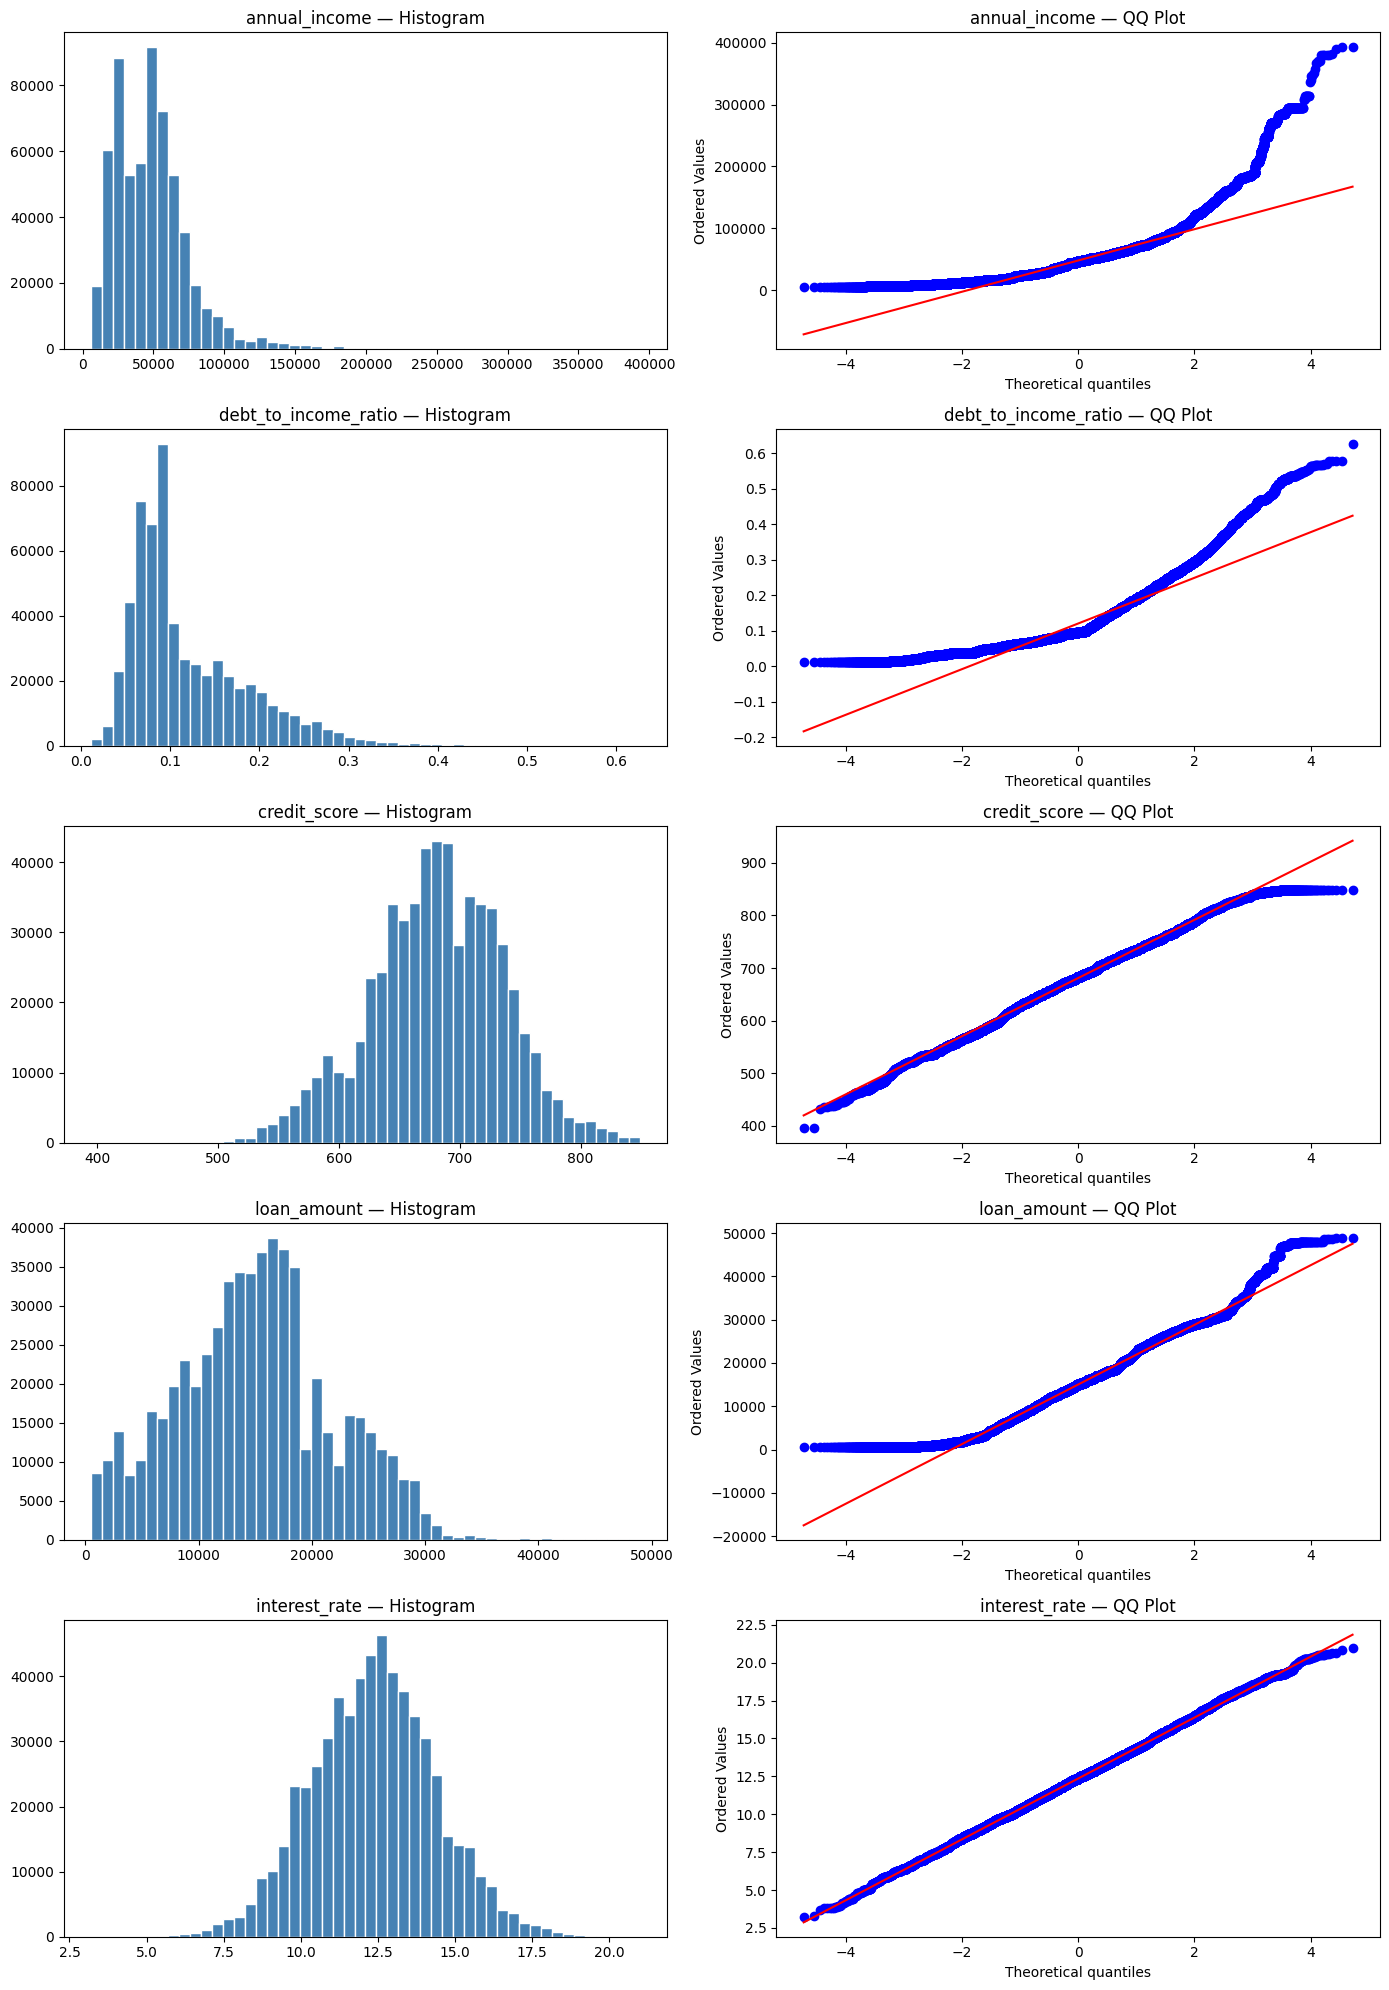

In [36]:
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(14, 20))

for i, col in enumerate(numerical_cols):
    # Histogram
    axes[i, 0].hist(train[col], bins=50, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col} — Histogram')
    
    # QQ Plot
    stats.probplot(train[col], dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'{col} — QQ Plot')

plt.tight_layout()
plt.show()

**Observations (Histogram + QQ Plot):**

- `annual_income`: strongly right-skewed with extreme upper-tail outliers — QQ confirms clear non-normality.
- `debt_to_income_ratio`: right-skewed with values concentrated near 0.1 — QQ shows substantial deviation from normality
- `credit_score`: roughly symmetric, minimal outliers — QQ indicates approximately normal distribution
- `loan_amount`: mildly right-skewed with irregular bumpy shape — QQ S-curve confirms non-normality
- `interest_rate`: symmetric bell, QQ nearly perfect fit.

Those three with non-normality need to be further investigated

In [38]:
print(train[numerical_cols].kurtosis().round(2))

annual_income           7.09
debt_to_income_ratio    2.34
credit_score            0.10
loan_amount            -0.15
interest_rate           0.06
dtype: float64


**Observations (Kurtosis):**

- `annual_income`: 7.09 extremely heavy tails, extreme outliers confirmed — explains QQ upper tail shooting away
- `loan_amount`: lighter tails than normal — non-normality driven by clustering not outliers
- `credit_score` normal tail behavior, no outlier concern
- `interest_rate`: normal tail behavior, no outlier concern
- `debt_to_income_ratio`: moderately heavy tails, outliers present but less severe — explains QQ curving

**Additionally**

all numerical features may require scaling — they're on completely different scales:

`annual_income`: 6k–393k
`credit_score`: 395–849
`loan_amount`: 500–49k
`debt_to_income_ratio`: 0.01–0.63
`interest_rate`: 3.2–21

**Str values:**

In [41]:
for col in train.select_dtypes(include='str').columns:
    print(f"\n{col}:")
    print(train[col].value_counts(normalize=True).round(3))


gender:
gender
Female    0.515
Male      0.478
Other     0.006
Name: proportion, dtype: float64

marital_status:
marital_status
Single      0.486
Married     0.467
Divorced    0.036
Widowed     0.011
Name: proportion, dtype: float64

education_level:
education_level
Bachelor's     0.471
High School    0.309
Master's       0.157
Other          0.045
PhD            0.019
Name: proportion, dtype: float64

employment_status:
employment_status
Employed         0.759
Unemployed       0.105
Self-employed    0.088
Retired          0.028
Student          0.020
Name: proportion, dtype: float64

loan_purpose:
loan_purpose
Debt consolidation    0.547
Other                 0.108
Car                   0.098
Home                  0.074
Education             0.062
Business              0.059
Medical               0.038
Vacation              0.014
Name: proportion, dtype: float64

grade_subgrade:
grade_subgrade
C3    0.099
C4    0.094
C2    0.092
C1    0.090
C5    0.090
D1    0.062
D3    0.062
D4    0

**Observations (Relative Frequency Distribution):**

- `gender`: balanced — Female 51.5%, Male 47.8%, Other 0.6% is a rare category, may need to be addressed
- `marital_status`: balanced between Single/Married (~95%) — Divorced  and Widowed  are rare, may need adressed
- `education_level`: Bachelor's dominant (47.1%) — PhD  and Other  are rare, natural ordinal order exists
- `employment_status`: strongly imbalanced — Employed dominates at 75.9%, Retired and Student are rare categories
- `loan_purpose`: imbalanced — Debt consolidation dominates at 54.7%, Vacation and Medical are rare
- `grade_subgrade`: C-grade dominates (~46% combined) with 30 categories total — high cardinality, A-grades extremely rare,
   ordinal structure exists.